# The attention value of a win in mixed martial arts

Figures and abstract for the SSAC 2027 submission.
Pre-registered: **OSF 10.17605/OSF.IO/DXUPH**. Analysis lives in `prep/z_analysis.py`;
this notebook only reads its outputs and draws.

Run top to bottom. Figures are written to `figures/` at 300 dpi.


In [1]:
import csv, math, sys
from pathlib import Path
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA, FIGS = ROOT / "data", ROOT / "figures"
FIGS.mkdir(exist_ok=True)

# Validated categorical pair (dataviz skill: ALL CHECKS PASS, light surface).
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, INK2, SURFACE = "#0b0b0b", "#52514e", "#fcfcfb"

mpl.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 300, "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 9, "axes.labelsize": 9, "axes.titlesize": 10,
    "axes.edgecolor": "#d8d7d2", "axes.linewidth": 0.8, "axes.grid": False,
    "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.labelcolor": INK, "xtick.major.width": 0.8, "ytick.major.width": 0.8,
    "legend.frameon": False,
})
print("ready")

ready


In [2]:
# --- data -------------------------------------------------------------------
bouts = {int(r["bout_id"]): r for r in csv.DictReader(open(DATA / "bout_D_S.csv"))}
strikes = {int(r["bout_id"]): r for r in csv.DictReader(open(DATA / "b_sig_strikes.csv"))
           if r["winner_share"]}

p, D = [], []
for bid, b in bouts.items():
    if b["in_sample_b"] == "True" and bid in strikes:
        p.append(float(strikes[bid]["winner_share"]) - 0.5)
        D.append(float(b["D"]))
p, D = np.array(p), np.array(D)
X = np.column_stack([np.ones(len(p)), p])
alpha, beta = np.linalg.lstsq(X, D, rcond=None)[0]
print(f"n = {len(p)}   alpha = {alpha:+.3f}   beta = {beta:+.3f}")

n = 309   alpha = +0.283   beta = +0.789


## Figure 1 — the attention gap at equal output

Each point is one split decision: how much the winner's strike share exceeded the
loser's (x) against the difference in their attention change (y). The fitted line's
height **at x = 0** — where both fighters landed equally — is the label effect.

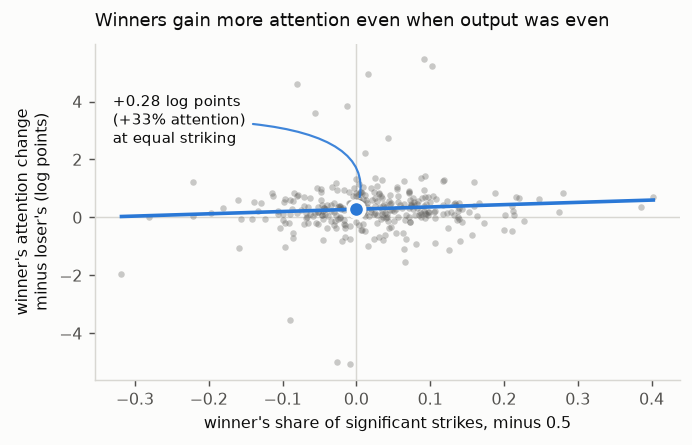

In [3]:
fig, ax = plt.subplots(figsize=(5.4, 3.5))

ax.axhline(0, color="#d8d7d2", lw=0.8, zorder=1)
ax.axvline(0, color="#d8d7d2", lw=0.8, zorder=1)
ax.scatter(p, D, s=13, color=INK2, alpha=0.30, linewidths=0, zorder=2)

xs = np.linspace(p.min(), p.max(), 100)
ax.plot(xs, alpha + beta * xs, color=BLUE, lw=2, zorder=4)

# the headline: the intercept
ax.plot([0], [alpha], marker="o", ms=9, color=BLUE, mec=SURFACE, mew=2, zorder=5)
ax.annotate(f"+{alpha:.2f} log points\n(+{100*(math.exp(alpha)-1):.0f}% attention)\nat equal striking",
            xy=(0, alpha), xytext=(-0.33, 4.3),
            color=INK, fontsize=8.5, ha="left", va="top",
            arrowprops=dict(arrowstyle="-", color=BLUE, lw=1.2, alpha=0.9,
                            connectionstyle="angle3,angleA=0,angleB=70",
                            shrinkA=2, shrinkB=7))

ax.set_xlabel("winner's share of significant strikes, minus 0.5")
ax.set_ylabel("winner's attention change\nminus loser's (log points)")
ax.set_title("Winners gain more attention even when output was even", loc="left",
             color=INK, pad=10)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig(FIGS / "fig1_label_effect.png", bbox_inches="tight")
plt.show()

## Figure 2 — what moves attention, and what does not

Point estimates with 95% bootstrap intervals (10,000 resamples of bouts).
Blue: the pre-registered confirmatory estimates. Orange: the placebo, which should
sit at zero, and the descriptive comparison.

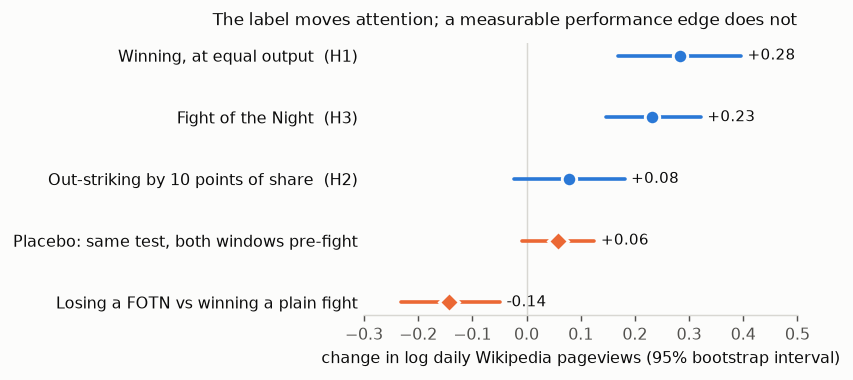

In [4]:
rows = [
    ("Winning, at equal output  (H1)",            alpha,   0.1687,  0.3960, BLUE,   "o"),
    ("Fight of the Night  (H3)",                  0.2322,  0.1462,  0.3218, BLUE,   "o"),
    # H2 rescaled to a 10-point strike-share edge so it is in the same units
    # (log points) as the level effects; the slope itself is +0.79 per unit.
    ("Out-striking by 10 points of share  (H2)",  0.0789, -0.0224, 0.1811, BLUE,   "o"),
    ("Placebo: same test, both windows pre-fight", 0.0581, -0.0082, 0.1254, ORANGE, "D"),
    ("Losing a FOTN vs winning a plain fight",    -0.1423, -0.2320, -0.0488, ORANGE, "D"),
]
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ys = np.arange(len(rows))[::-1]
ax.axvline(0, color="#d8d7d2", lw=0.8, zorder=1)
for y, (label, est, lo, hi, colour, marker) in zip(ys, rows):
    ax.plot([lo, hi], [y, y], color=colour, lw=2, solid_capstyle="round", zorder=3)
    ax.plot([est], [y], marker=marker, ms=8, color=colour, mec=SURFACE, mew=1.6, zorder=4)
    ax.text(hi + 0.012, y, f"{est:+.2f}", va="center", ha="left", color=INK, fontsize=8.5)

ax.set_yticks(ys)
ax.set_yticklabels([r[0] for r in rows], color=INK)
ax.set_xlabel("change in log daily Wikipedia pageviews (95% bootstrap interval)")
ax.set_title("The label moves attention; a measurable performance edge does not",
             loc="right", color=INK, pad=10, fontsize=9.5)
ax.set_xlim(-0.30, 0.50)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.tick_params(axis="y", length=0)
fig.tight_layout()
fig.savefig(FIGS / "fig2_estimates.png", bbox_inches="tight")
plt.show()

## Abstract (draft)

**The attention value of a win in mixed martial arts**

**Introduction.** Attention concentrates on winners, but why is unclear. Rosen's
superstar account says attention tracks talent, amplified. Adler's says it can
attach to an arbitrary early advantage and compound through shared consumption. The
two are hard to separate, because winners usually did perform better. Split
decisions break the tie: the judges disagreed, so performance was near-equal, while
the official label is close to arbitrary. What is the label alone worth?

**Methods.** All 562 UFC split decisions from 2015-08-30 to 2026-08-20; 314 where both
fighters had an English Wikipedia article at least 60 days old, and 309 with fight
statistics. For each fighter, attention is the change in log mean daily Wikipedia
pageviews from days −60..−8 before the fight to days +2..+30 after, excluding fight
week. D is the winner's change minus the loser's; p is the winner's share of
significant strikes landed, minus 0.5. Fitting D = α + β·p, α is the gap when output
was even and β the return to out-striking. A third test asks whether Fight of the
Night bouts (1,508 decision bouts, 147 awarded) draw more attention. Pre-registered
at OSF 10.17605/OSF.IO/DXUPH before any post-fight data was collected; intervals
bootstrap over bouts, standard errors cluster on both fighters, Holm across the
three tests.

**Results.** The win label is worth **+0.28 log points, a 33% attention gap**
(95% CI 0.17–0.40, p < 0.001) between two fighters who landed equally. The return to
out-striking is **not distinguishable from zero** (β = 0.79, CI −0.22–1.81), and the
study can only detect effects above roughly 10%, so this is inconclusive rather than
null. Fight of the Night is worth **+0.23 log points, 26%** (CI 0.15–0.32,
p < 0.001). Two cautions, both pre-specified: a placebo run on two pre-fight windows
returns +0.06 (CI −0.01–0.13), so eventual winners were already drifting upward, and
α should be read net of it. And losing an entertaining fight is **not** as good as
winning a dull one: FOTN losers gain 13% less than ordinary winners (p = 0.003).

**Conclusion.** In fights judges could not separate, the official result alone moves
public attention about as much as being in the night's best fight, while the
performance edge we can measure moves it undetectably. Attention here attaches to
the label rather than to the output behind it — Adler over Rosen, for close fights.
The measure of performance is a fight-total striking proxy, not round-by-round
judging, so β bounds what strikes can explain rather than what performance can.

In [5]:
# Word count of the abstract markdown cell above (SSAC limit: 500).
import nbformat, re
nb = nbformat.read(ROOT / "notebooks" / "abstract.ipynb", as_version=4)
cell = next(c.source for c in nb.cells
            if c.cell_type == "markdown" and c.source.lstrip().startswith("## Abstract"))
body = cell.split("**The attention value", 1)[1]
body = re.sub(r"[*_`#]", " ", body)
words = [w for w in body.split() if any(ch.isalnum() for ch in w)]
print(f"{len(words)} words (limit 500)")

411 words (limit 500)


/Users/baptisteperrier/code/baptperr/SSAC27/.venv/lib/python3.12/site-packages/nbformat/validator.py:434: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  _validate(nbdict, ref, version, version_minor, relax_add_props)
